In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from pathlib import Path

In [14]:
raw_data = pd.read_csv('final_hcris.csv')
data_2009 = pd.read_csv('data/output/data-2009.csv')
data_2010 = pd.read_csv('data/output/data-2010.csv')
data_2011 = pd.read_csv('data/output/data-2011.csv')
data_2012 = pd.read_csv('data/output/data-2012.csv')
data_2013 = pd.read_csv('data/output/data-2013.csv')
data_2014 = pd.read_csv('data/output/data-2014.csv')
data_2015 = pd.read_csv('data/output/data-2015.csv')
data_2016 = pd.read_csv('data/output/data-2016.csv')
data_2017 = pd.read_csv('data/output/data-2017.csv')
data_2018 = pd.read_csv('data/output/data-2018.csv')
data_2019 = pd.read_csv('data/output/data-2019.csv')
data = pd.concat([data_2009, data_2010, data_2011, data_2012, data_2013, data_2014, data_2015, data_2016, data_2017, data_2018, data_2019], ignore_index=True)

## Question 1

In [15]:
question_1 = (
    raw_data
    .groupby(["fyear", "provider_number"])
    .size()
    .reset_index(name="num_reports")
)
multiple_reports = question_1[question_1["num_reports"] > 1]
multiple_reports.head()

,fyear,provider_number,num_reports
177,2009,40069,2
179,2009,40081,2
197,2009,41316,2
295,2009,50313,2
332,2009,50528,2


In [16]:
hospitals_per_year = (
    multiple_reports
    .groupby("fyear")
    .size()
    .reindex(range(2009, 2020), fill_value=0)
    .reset_index(name="num_hospitals")
)
hospitals_per_year

,fyear,num_hospitals
0,2009,37
1,2010,0
2,2011,45
3,2012,90
4,2013,91
5,2014,102
6,2015,96
7,2016,95
8,2017,91
9,2018,101


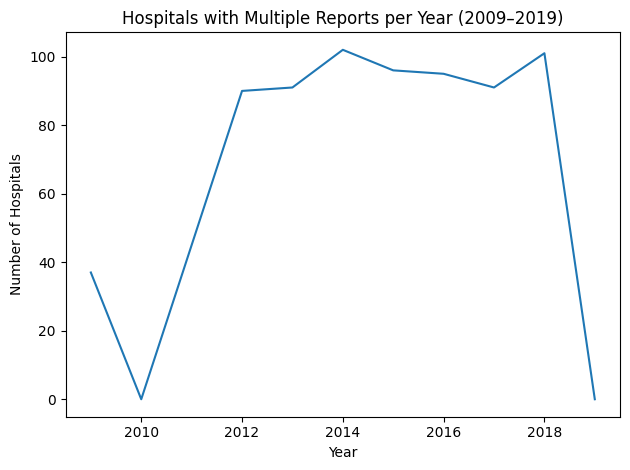

In [17]:
fig, ax = plt.subplots()

ax.plot(
    hospitals_per_year["fyear"],
    hospitals_per_year["num_hospitals"]
)
ax.set(
    xlabel="Year", 
    ylabel="Number of Hospitals",
    title="Hospitals with Multiple Reports per Year (2009–2019)"
)

plt.tight_layout()
plt.show()

## Question 2

In [18]:
data['provider_number'].nunique()

6793

There are 6793 unique hospital IDs. 

## Question 3

In [36]:
df_plot = raw_data[(raw_data["fyear"] >= 2009) & (raw_data["fyear"] <= 2019)].copy()

df_plot["tot_charges"] = pd.to_numeric(df_plot["tot_charges"], errors="coerce")

df_plot = df_plot.dropna(subset=["tot_charges", "fyear"])
df_plot = df_plot[df_plot["tot_charges"] > 0]

lower = df_plot["tot_charges"].quantile(0.01)
upper = df_plot["tot_charges"].quantile(0.99)
df_plot = df_plot[
    (df_plot["tot_charges"] >= lower) &
    (df_plot["tot_charges"] <= upper)
].copy()

df_plot["log_tot_charges"] = np.log(df_plot["tot_charges"])

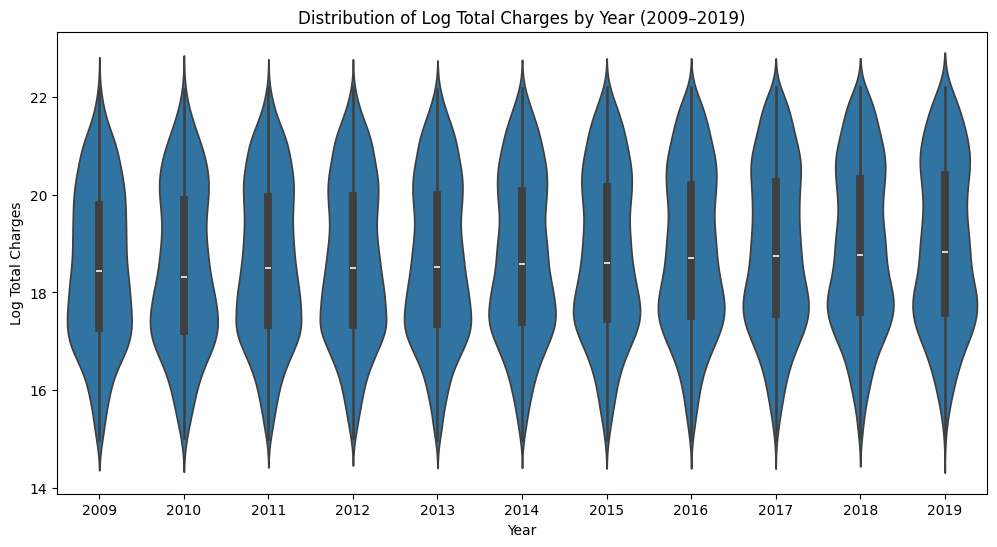

In [37]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_plot,
    x="fyear",
    y="log_tot_charges"
)

plt.title("Distribution of Log Total Charges by Year (2009–2019)")
plt.xlabel("Year")
plt.ylabel("Log Total Charges")
plt.show()

## Question 4

In [38]:
raw_data["discount_factor"] = 1 - (raw_data["tot_discounts"] / raw_data["tot_charges"])

raw_data["price_num"] = (
    raw_data["ip_charges"] +
    raw_data["icu_charges"] +
    raw_data["ancillary_charges"]
) * raw_data["discount_factor"] - raw_data["tot_mcare_payment"]

raw_data["price_denom"] = raw_data["tot_discharges"] - raw_data["mcare_discharges"]

raw_data["price"] = raw_data["price_num"] / raw_data["price_denom"]

In [39]:
df_plot = raw_data.copy()

df_plot = df_plot[(df_plot["fyear"] >= 2009) & (df_plot["fyear"] <= 2019)]

df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=["price"])

df_plot = df_plot[df_plot["price"] > 0]

In [40]:
lower = df_plot["price"].quantile(0.01)
upper = df_plot["price"].quantile(0.99)

df_plot = df_plot[
    (df_plot["price"] >= lower) &
    (df_plot["price"] <= upper)
].copy()

In [41]:
df_plot["log_price"] = np.log(df_plot["price"])

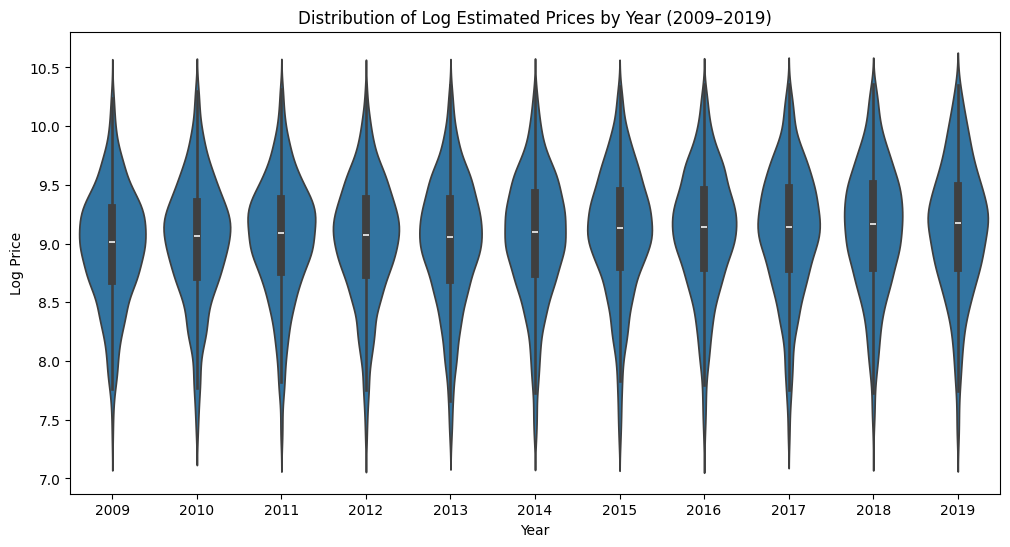

In [43]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_plot,
    x="fyear",
    y="log_price"
)

plt.title("Distribution of Log Estimated Prices by Year (2009–2019)")
plt.xlabel("Year")
plt.ylabel("Log Price")

plt.show()

## Question 5

In [49]:
df_pen = raw_data.copy()

df_pen = df_pen[(df_pen["fyear"] >= 2012) & (df_pen["fyear"] <= 2019)]

df_pen["hrrp_payment"] = pd.to_numeric(df_pen["hrrp_payment"], errors="coerce")
df_pen["hvbp_payment"] = pd.to_numeric(df_pen["hvbp_payment"], errors="coerce")

df_pen["hrrp_payment"] = df_pen["hrrp_payment"].fillna(0)
df_pen["hvbp_payment"] = df_pen["hvbp_payment"].fillna(0)

df_pen["net_payment"] = df_pen["hrrp_payment"] + df_pen["hvbp_payment"]

df_pen["penalized"] = (df_pen["net_payment"] > 0).astype(int)

share_pen = (
    df_pen.groupby("fyear")["penalized"]
    .mean()
    .reset_index()
)

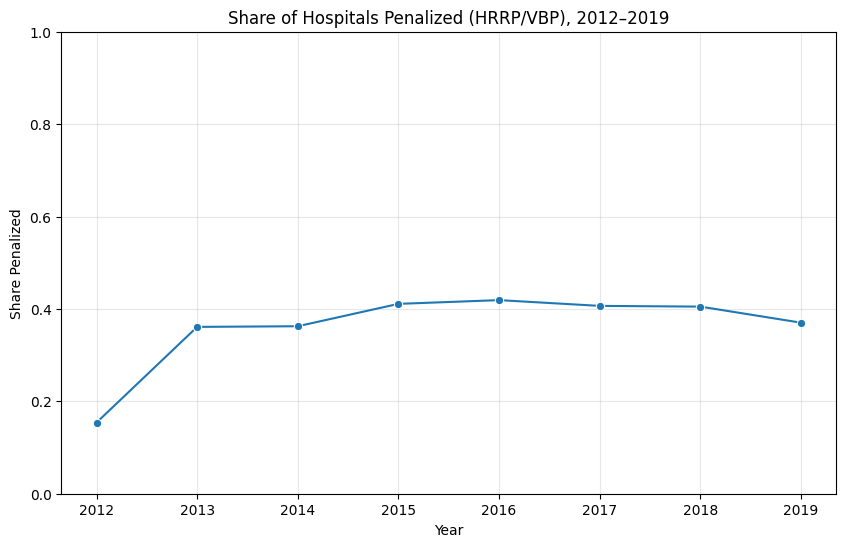

In [50]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=share_pen,
    x="fyear",
    y="penalized",
    marker="o"
)

plt.title("Share of Hospitals Penalized (HRRP/VBP), 2012–2019")
plt.xlabel("Year")
plt.ylabel("Share Penalized")
plt.ylim(0, 1)

plt.grid(True, alpha=0.3)

plt.show()

## Question 6*

In [51]:
from statsmodels.iolib.summary2 import summary_col

df = raw_data.copy()

num_vars = [
    "tot_discounts", "tot_charges", "ip_charges", "icu_charges",
    "ancillary_charges", "tot_mcare_payment", "tot_discharges",
    "mcare_discharges", "mcaid_discharges", "beds",
    "hrrp_payment", "hvbp_payment"
]

for v in num_vars:
    df[v] = pd.to_numeric(df[v], errors="coerce")

df["discount_factor"] = 1 - df["tot_discounts"] / df["tot_charges"]
df["price_num"] = (
    (df["ip_charges"] + df["icu_charges"] + df["ancillary_charges"]) * df["discount_factor"]
    - df["tot_mcare_payment"]
)
df["price_denom"] = df["tot_discharges"] - df["mcare_discharges"]
df["price"] = df["price_num"] / df["price_denom"]

df = df.replace([np.inf, -np.inf], np.nan)
df.loc[df["price"] <= 0, "price"] = np.nan

df["net_penalty"] = df["hrrp_payment"].fillna(0) + df["hvbp_payment"].fillna(0)

price_2011 = (
    df.loc[df["fyear"] == 2011, ["provider_number", "price"]]
      .rename(columns={"price": "price_2011"})
)

price_2014 = (
    df.loc[df["fyear"] == 2014, ["provider_number", "price"]]
      .rename(columns={"price": "price_2014"})
)

pen_2012 = (
    df.loc[df["fyear"] == 2012, ["provider_number", "net_penalty"]]
      .rename(columns={"net_penalty": "net_penalty_2012"})
)

pre_period = df.loc[df["fyear"].between(2009, 2011)].copy()

pre_means = (
    pre_period.groupby("provider_number", as_index=False)
    .agg(
        mean_beds_pre=("beds", "mean"),
        mean_mcaid_discharges_pre=("mcaid_discharges", "mean"),
        mean_mcare_discharges_pre=("mcare_discharges", "mean")  # useful later for IV
    )
)

analysis = (
    price_2011
    .merge(price_2014, on="provider_number", how="inner")
    .merge(pen_2012, on="provider_number", how="inner")
    .merge(pre_means, on="provider_number", how="inner")
)

analysis["price_change"] = analysis["price_2014"] - analysis["price_2011"]

analysis_ols = analysis.dropna(subset=[
    "price_change",
    "net_penalty_2012",
    "mean_beds_pre",
    "mean_mcaid_discharges_pre"
]).copy()

ols1 = smf.ols(
    "price_change ~ net_penalty_2012",
    data=analysis_ols
).fit(cov_type="HC1")

ols2 = smf.ols(
    "price_change ~ net_penalty_2012 + mean_beds_pre",
    data=analysis_ols
).fit(cov_type="HC1")

ols3 = smf.ols(
    "price_change ~ net_penalty_2012 + mean_beds_pre + mean_mcaid_discharges_pre",
    data=analysis_ols
).fit(cov_type="HC1")

results_table = summary_col(
    [ols1, ols2, ols3],
    stars=True,
    model_names=["(1)", "(2)", "(3)"],
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}"
    }
)

print(results_table)


                             (1)        (2)        (3)    
----------------------------------------------------------
Intercept                 750.0373*  731.5835*  575.0409  
                          (387.6428) (382.6983) (456.0059)
net_penalty_2012          -0.0014    -0.0014    -0.0017   
                          (0.0030)   (0.0030)   (0.0029)  
mean_beds_pre                        0.0696*    0.0652*   
                                     (0.0374)   (0.0345)  
mean_mcaid_discharges_pre                       0.0994    
                                                (0.0818)  
R-squared                 0.0000     0.0001     0.0002    
R-squared Adj.            -0.0004    -0.0007    -0.0010   
N                         2476       2476       2476      
R2                        0.000      0.000      0.000     
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Question 7

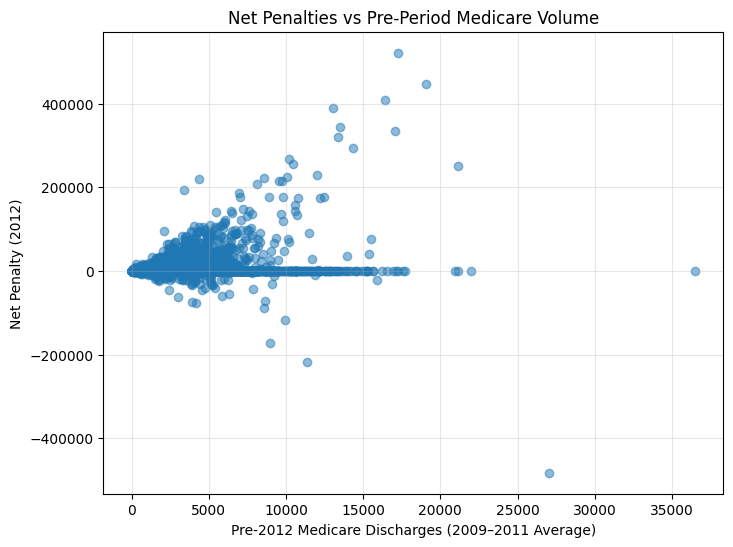

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis["mean_mcare_discharges_pre"],
    analysis["net_penalty_2012"],
    alpha=0.5
)

plt.xlabel("Pre-2012 Medicare Discharges (2009–2011 Average)")
plt.ylabel("Net Penalty (2012)")
plt.title("Net Penalties vs Pre-Period Medicare Volume")

plt.grid(True, alpha=0.3)

plt.show()

<Axes: xlabel='mean_mcare_discharges_pre', ylabel='net_penalty_2012'>

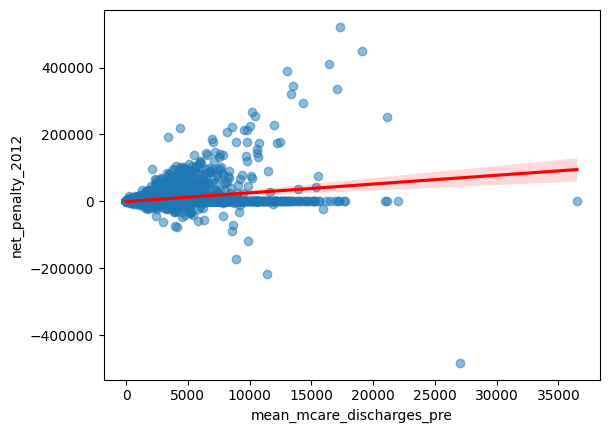

In [53]:
sns.regplot(
    data=analysis,
    x="mean_mcare_discharges_pre",
    y="net_penalty_2012",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

## Question 8*

In [54]:
fs1 = smf.ols(
    "net_penalty_2012 ~ mean_mcare_discharges_pre",
    data=analysis
).fit(cov_type="HC1")

fs2 = smf.ols(
    "net_penalty_2012 ~ mean_mcare_discharges_pre + mean_beds_pre",
    data=analysis
).fit(cov_type="HC1")

fs3 = smf.ols(
    "net_penalty_2012 ~ mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre",
    data=analysis
).fit(cov_type="HC1")

In [55]:
rf1 = smf.ols(
    "price_change ~ mean_mcare_discharges_pre",
    data=analysis
).fit(cov_type="HC1")

rf2 = smf.ols(
    "price_change ~ mean_mcare_discharges_pre + mean_beds_pre",
    data=analysis
).fit(cov_type="HC1")

rf3 = smf.ols(
    "price_change ~ mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre",
    data=analysis
).fit(cov_type="HC1")

In [56]:
from statsmodels.iolib.summary2 import summary_col

results_iv = summary_col(
    [fs1, fs2, fs3, rf1, rf2, rf3],
    stars=True,
    model_names=[
        "FS (1)", "FS (2)", "FS (3)",
        "RF (1)", "RF (2)", "RF (3)"
    ],
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}"
    }
)

print(results_iv)


                            FS (1)     FS (2)     FS (3)     RF (1)     RF (2)     RF (3)  
-------------------------------------------------------------------------------------------
Intercept                 -746.2921  -741.4747  -524.0161  -1028.1612 -1032.1631 -186.8785 
                          (781.1427) (781.4592) (820.0418) (962.0695) (962.4081) (439.6975)
mean_mcare_discharges_pre 2.6253***  2.6310***  3.1244***  0.3891     0.3866     0.3132    
                          (0.5237)   (0.5235)   (0.6102)   (0.2720)   (0.2721)   (0.3462)  
mean_beds_pre                        -0.1024**  -0.0761***            0.0484***  0.0456*** 
                                     (0.0467)   (0.0253)              (0.0095)   (0.0084)  
mean_mcaid_discharges_pre                       -1.3291***                       -0.1386   
                                                (0.4334)                         (0.3140)  
R-squared                 0.0818     0.0818     0.0852     0.0023     0.0023   

## Question 9*

In [90]:
from linearmodels.iv import IV2SLS

df = raw_data.copy()

num_vars = [
    "tot_discounts", "tot_charges", "ip_charges", "icu_charges",
    "ancillary_charges", "tot_mcare_payment", "tot_discharges",
    "mcare_discharges", "mcaid_discharges", "beds",
    "hrrp_payment", "hvbp_payment", "fyear"
]

for v in num_vars:
    df[v] = pd.to_numeric(df[v], errors="coerce")

In [91]:
df["discount_factor"] = 1 - (df["tot_discounts"] / df["tot_charges"])

df["price_num"] = (
    (df["ip_charges"] + df["icu_charges"] + df["ancillary_charges"]) * df["discount_factor"]
    - df["tot_mcare_payment"]
)

df["price_denom"] = df["tot_discharges"] - df["mcare_discharges"]
df["price"] = df["price_num"] / df["price_denom"]

df = df.replace([np.inf, -np.inf], np.nan)
df.loc[df["price"] <= 0, "price"] = np.nan

In [92]:
df["net_penalty"] = df["hrrp_payment"].fillna(0) + df["hvbp_payment"].fillna(0)

price_2011 = (
    df.loc[df["fyear"] == 2011, ["provider_number", "price"]]
      .rename(columns={"price": "price_2011"})
)

price_2014 = (
    df.loc[df["fyear"] == 2014, ["provider_number", "price"]]
      .rename(columns={"price": "price_2014"})
)

pen_2012 = (
    df.loc[df["fyear"] == 2012, ["provider_number", "net_penalty"]]
      .rename(columns={"net_penalty": "net_penalty_2012"})
)

pre_period = df.loc[df["fyear"].between(2009, 2011)].copy()

pre_means = (
    pre_period.groupby("provider_number", as_index=False)
    .agg(
        mean_mcare_discharges_pre=("mcare_discharges", "mean"),
        mean_beds_pre=("beds", "mean"),
        mean_mcaid_discharges_pre=("mcaid_discharges", "mean")
    )
)

analysis = (
    price_2011
    .merge(price_2014, on="provider_number", how="inner")
    .merge(pen_2012, on="provider_number", how="inner")
    .merge(pre_means, on="provider_number", how="inner")
)

analysis["price_change"] = analysis["price_2014"] - analysis["price_2011"]

analysis_iv = analysis.dropna(subset=[
    "price_change",
    "net_penalty_2012",
    "mean_mcare_discharges_pre",
    "mean_beds_pre",
    "mean_mcaid_discharges_pre"
]).copy()

In [93]:
iv1 = IV2SLS.from_formula(
    "price_change ~ 1 + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv
).fit(cov_type="robust")

iv2 = IV2SLS.from_formula(
    "price_change ~ 1 + mean_beds_pre + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv
).fit(cov_type="robust")

iv3 = IV2SLS.from_formula(
    "price_change ~ 1 + mean_beds_pre + mean_mcaid_discharges_pre + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv
).fit(cov_type="robust")

In [94]:
iv_table = pd.DataFrame({
    "(1)": [
        iv1.params.get("Intercept", np.nan),
        iv1.std_errors.get("Intercept", np.nan),
        iv1.params.get("net_penalty_2012", np.nan),
        iv1.std_errors.get("net_penalty_2012", np.nan),
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        int(iv1.nobs),
        iv1.rsquared
    ],
    "(2)": [
        iv2.params.get("Intercept", np.nan),
        iv2.std_errors.get("Intercept", np.nan),
        iv2.params.get("net_penalty_2012", np.nan),
        iv2.std_errors.get("net_penalty_2012", np.nan),
        iv2.params.get("mean_beds_pre", np.nan),
        iv2.std_errors.get("mean_beds_pre", np.nan),
        np.nan,
        np.nan,
        int(iv2.nobs),
        iv2.rsquared
    ],
    "(3)": [
        iv3.params.get("Intercept", np.nan),
        iv3.std_errors.get("Intercept", np.nan),
        iv3.params.get("net_penalty_2012", np.nan),
        iv3.std_errors.get("net_penalty_2012", np.nan),
        iv3.params.get("mean_beds_pre", np.nan),
        iv3.std_errors.get("mean_beds_pre", np.nan),
        iv3.params.get("mean_mcaid_discharges_pre", np.nan),
        iv3.std_errors.get("mean_mcaid_discharges_pre", np.nan),
        int(iv3.nobs),
        iv3.rsquared
    ]
}, index=[
    "Intercept",
    "Intercept SE",
    "Net Penalty (IV)",
    "Net Penalty SE",
    "Avg Beds (Pre-2012)",
    "Beds SE",
    "Avg Medicaid Discharges (Pre-2012)",
    "Medicaid SE",
    "Num. Obs.",
    "R2"
])

iv_table = iv_table.round(4)
print(iv_table)

                                          (1)        (2)        (3)
Intercept                           -206.1669  -210.9052  -214.0886
Intercept SE                         576.3327   575.7533   533.7880
Net Penalty (IV)                       0.1141     0.1129     0.1118
Net Penalty SE                         0.1102     0.1099     0.1282
Avg Beds (Pre-2012)                       NaN     0.0537     0.0535
Beds SE                                   NaN     0.0120     0.0133
Avg Medicaid Discharges (Pre-2012)        NaN        NaN     0.0078
Medicaid SE                               NaN        NaN     0.1683
Num. Obs.                           2476.0000  2476.0000  2476.0000
R2                                    -0.0488    -0.0477    -0.0468


## Question 10

The IV estimate identifies a local ATE, reflecting the effect of penalties on prices for hospitals whose penalty status is influenced affected by their pre-2012 Medicare discharges. This effect applies mostly to hospitals with higher Medicare exposure and can be different from overall ATE, reflecing the average effect across all hospitals.